# Decsion Tree Regression

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("Desion_Tree_Regression.csv")

print(df.head())


  Make       Model  Year             Engine Fuel Type  Engine HP  \
0  BMW  1 Series M  2011  premium unleaded (required)      335.0   
1  BMW    1 Series  2011  premium unleaded (required)      300.0   
2  BMW    1 Series  2011  premium unleaded (required)      300.0   
3  BMW    1 Series  2011  premium unleaded (required)      230.0   
4  BMW    1 Series  2011  premium unleaded (required)      230.0   

   Engine Cylinders Transmission Type     Driven_Wheels  Number of Doors  \
0               6.0            MANUAL  rear wheel drive              2.0   
1               6.0            MANUAL  rear wheel drive              2.0   
2               6.0            MANUAL  rear wheel drive              2.0   
3               6.0            MANUAL  rear wheel drive              2.0   
4               6.0            MANUAL  rear wheel drive              2.0   

                         Market Category Vehicle Size Vehicle Style  \
0  Factory Tuner,Luxury,High-Performance      Compact         C

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [9]:
# Fill missing numeric values with median
df["Engine HP"].fillna(df["Engine HP"].median(), inplace=True)
df["Engine Cylinders"].fillna(df["Engine Cylinders"].median(), inplace=True)
df["Number of Doors"].fillna(df["Number of Doors"].median(), inplace=True)

# Encode categorical features

In [12]:
categorical_cols = ["Make","Model","Engine Fuel Type","Transmission Type",
                    "Driven_Wheels","Market Category","Vehicle Size","Vehicle Style"]

for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

In [14]:
X = df.drop(columns=["MSRP"])   # Features
y = df["MSRP"]                  # Target (car price)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
reg = DecisionTreeRegressor(max_depth=10,random_state=42)
reg.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [17]:
y_pred = reg.predict(X_test)
y_pred

array([30862.29268293, 23996.56842105, 34188.42920354, ...,
       19784.15178571, 20939.032     , 51250.        ])

In [18]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


MSE: 144986482.89692557
R² Score: 0.9391725503366454


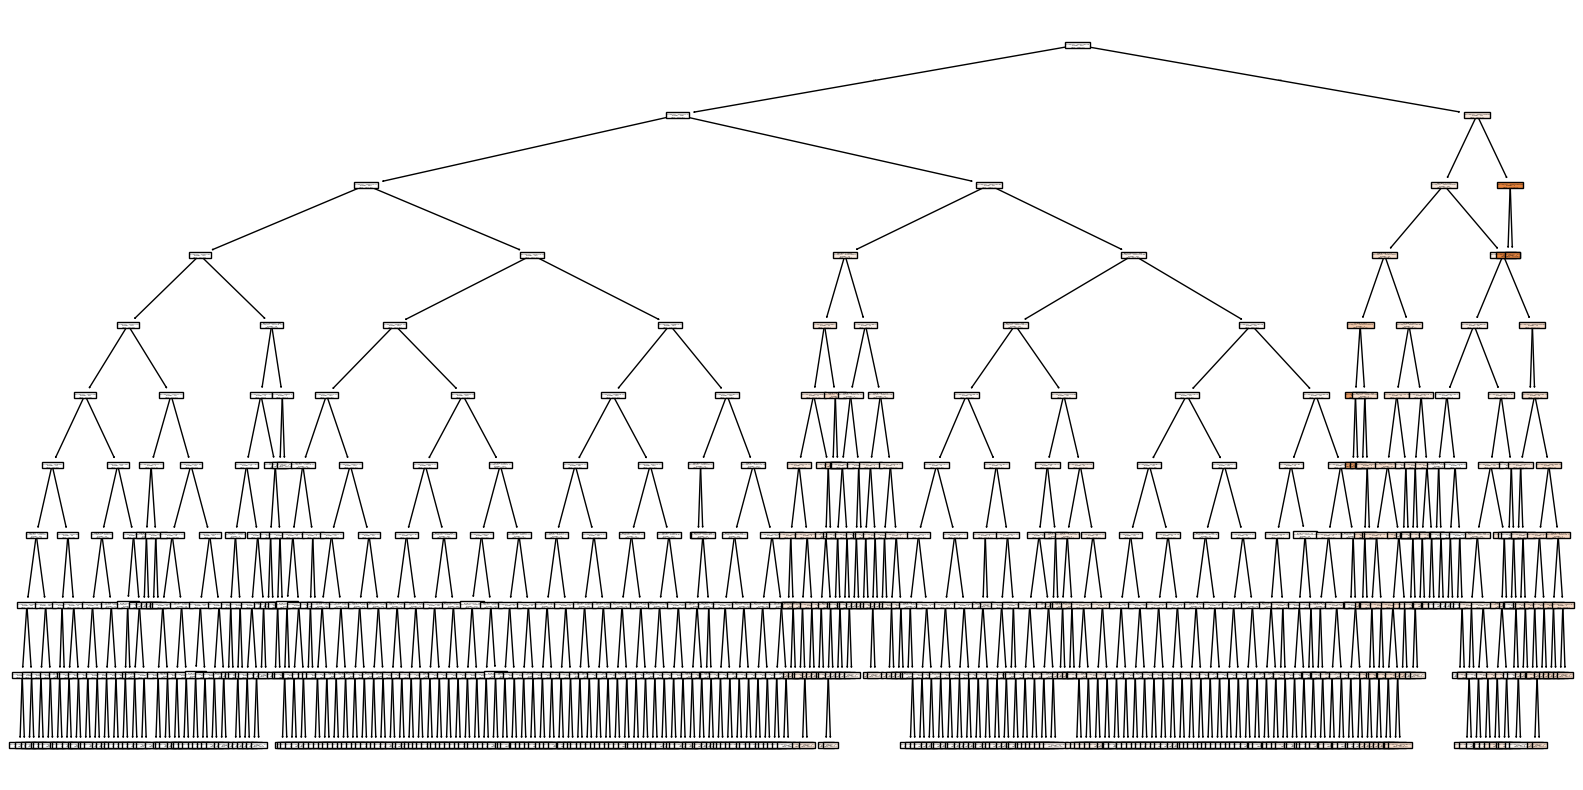

In [20]:
plt.figure(figsize=(20,10))
plot_tree(reg, feature_names=X.columns, filled=True)
plt.show()
